# <img style="float: left; padding-right: 20px; width: 200px" src="https://github.com/ymotomy/ymotomy.github.io/blob/main/imagenes/UC.png?raw=true">  IMT2118 - Ciencia de Datos Geoespaciales
**Pontificia Universidad Católica de Chile**<br>
**Semestre 2025-1**<br>
**Estudiantes:** Christian Camilo | Tomás Romero <br>
---

<hr>
<h1 style="text-align:center;"> Recomendador de Localizaciones para Observatorios en Chile usando Imágenes Satelitales y Datos Raster/Vectoriales

Chile se ha consolidado como uno de los destinos más privilegiados del mundo para la observación astronómica, gracias a sus cielos despejados, baja humedad atmosférica y reducida contaminación lumínica en vastas zonas del norte del país. Sin embargo, con el crecimiento urbano, el cambio climático y el avance de la infraestructura, resulta cada vez más necesario identificar nuevos sitios potenciales que maximicen las condiciones óptimas para la instalación de observatorios astronómicos.

Este proyecto propone el desarrollo de un sistema de recomendación basado en análisis multicriterio espacial para predecir zonas favorables para la construcción de observatorios en Chile. Para ello, se utilizarán imágenes satelitales y datos geoespaciales provenientes de diversas fuentes, tales como sensores MODIS, Sentinel-5P, Landsat y DMSP-OLS, combinando información sobre contaminación lumínica, cobertura nubosa, altitud, calidad del aire, uso de suelo y proximidad a centros urbanos.

A través del uso de herramientas como Google Earth Engine y Python, se desarrollará un flujo automatizado de procesamiento y análisis que permita integrar tanto datos raster como vectoriales. El resultado será una visualización dinámica e interactiva de los sitios más idóneos, que considere tanto criterios astronómicos como restricciones territoriales.

Este estudio busca no solo aplicar técnicas avanzadas de ciencia de datos geoespaciales, sino también contribuir a la planificación estratégica de infraestructura astronómica en Chile, promoviendo el uso sustentable del territorio en armonía con el desarrollo científico.
<hr>

In [1]:
#Primero importamos algunas librerias
import os
import glob
import requests
import geemap,ee
import numpy as np
import pandas as pd
from PIL import Image
from io import BytesIO
import geopandas as gpd

from matplotlib import colors
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shapely.geometry import shape, box
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon, Point

#Ignormaos los warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
ee.Authenticate()
# ee.Initialize(project='ee-ccamz2')
ee.Initialize(project='ee-tomasromero')

In [3]:
# Seleccionamos rango de fechas
startDate= '2024-01-01'
endDate = '2025-01-01'

## Observatorios

In [ ]:
obs = gpd.read_file("Datos/observatorios/observatorios.shp").to_crs(epsg=4326)
#nos quedatos con los tipo radio, opticos, infrarrojo
obs = obs[obs['Tipo'].isin(['Radio', 'Óptico', 'Infrarrojo', 'Óptico/Infrarrojo'])].reset_index(drop=True)
obs.head(1)

,Nombre,Altitud (m,Ubicación,Tipo,Estado,Año de In,Área Lent,geometry
0,ALMA,5000,"Llano de Chajnantor, Antofagasta",Radio,Operativo,2003,41001.06121734071,POINT (-67.7546 -23.0221)


## Mapa de Chile

In [5]:
chile = gpd.read_file('Datos/Comunas/Comunas.shp').to_crs(epsg=4326).to_crs(epsg=32719)
chile = chile[chile['codregion'].isin([1, 2, 3, 4])]

#Quitamos isla de pascua y juan fernandez
chile = chile[~chile['Comuna'].isin(['Isla de Pascua', 'Juan Fernández'])]

In [6]:
#Unimos todas las comunas en una figura

def keep_only_mainland(geom):
    if geom.geom_type == 'Polygon':
        return geom
    elif geom.geom_type == 'MultiPolygon':
        return max(geom.geoms, key=lambda g: g.area)
    return geom

chile['geometry'] = chile['geometry'].buffer(0)

chile['geometry'] = chile['geometry'].apply(keep_only_mainland)
chile = gpd.GeoDataFrame(geometry=[chile.unary_union], crs=chile.crs)

In [7]:
# Eliminar huecos interiores

def remove_holes(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(g.exterior) for g in geom.geoms])
    return geom

chile['geometry'] = chile['geometry'].apply(remove_holes)

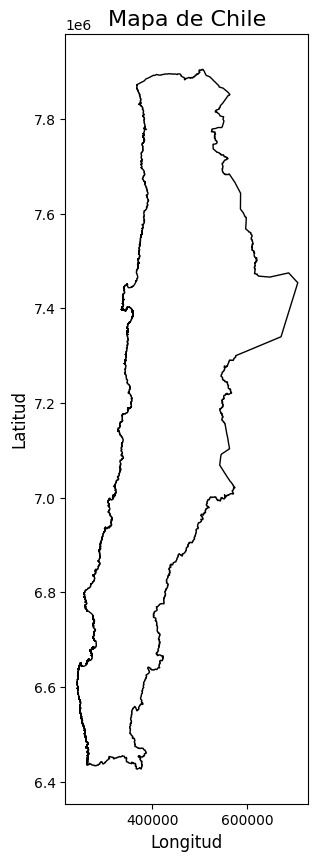

In [8]:
chile.plot(color='white', edgecolor='black', figsize=(10, 10))
# Añadir título y etiquetas
plt.title('Mapa de Chile', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.show()

### Creamos los hexagonos para Chile

In [9]:
# 6. Crear hexágonos
def create_hex_grid(gdf, hex_radius):
    bounds = gdf.total_bounds
    xmin, ymin, xmax, ymax = bounds
    dx = 3/2 * hex_radius
    dy = np.sqrt(3) * hex_radius
    cols = int((xmax - xmin) / dx) + 2
    rows = int((ymax - ymin) / dy) + 2

    hexes = []
    for row in range(rows):
        for col in range(cols):
            x = xmin + col * dx
            y = ymin + row * dy
            if col % 2 == 1:
                y += dy / 2
            hex = Polygon([
                (x + hex_radius * np.cos(np.radians(angle)),
                 y + hex_radius * np.sin(np.radians(angle)))
                for angle in range(0, 360, 60)
            ])
            hexes.append(hex)

    return gpd.GeoDataFrame(geometry=hexes, crs=gdf.crs)

In [ ]:
# hex_grid = create_hex_grid(chile, hex_radius=5000)
# hex_grid = gpd.overlay(hex_grid, chile, how='intersection').to_crs(epsg=4326)
# hex_grid

,geometry
0,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1..."
1,"POLYGON ((-70.43813 -32.20378, -70.38509 -32.2..."
2,"POLYGON ((-70.35916 -32.24371, -70.31138 -32.2..."
3,"MULTIPOLYGON (((-71.49633 -32.10922, -71.4709 ..."
4,"POLYGON ((-71.4709 -32.14876, -71.41793 -32.14..."
...,...
4684,"POLYGON ((-69.59911 -19.03382, -69.64662 -19.0..."
4685,"MULTIPOLYGON (((-69.50408 -19.03411, -69.50798..."
4686,"POLYGON ((-69.00517 -18.99566, -69.02893 -19.0..."
4687,"POLYGON ((-68.95766 -18.99566, -69.00517 -18.9..."


### Obtenemos los hexagonos para los observatorios fuera de Chile

In [ ]:
# #obtenemos los id de los hexagonos donde estan los observatorios
# obs_chile = obs[obs.geometry.within(hex_grid.unary_union)]
# obs_chile = obs_chile.reset_index(drop=True)
# obs_chile.head(1)

,Nombre,Altitud (m,Ubicación,Tipo,Estado,Año de In,Área Lent,geometry
0,ALMA,5000,"Llano de Chajnantor, Antofagasta",Radio,Operativo,2003,41001.06121734071,POINT (-67.7546 -23.0221)


In [ ]:
# # a obs le quitamos los observatorios que estan en obs_chile
# obs = obs[~obs.geometry.within(hex_grid.unary_union)]
# obs.head(1)

,Nombre,Altitud (m,Ubicación,Tipo,Estado,Año de In,Área Lent,geometry
11,Very Large Array (VLA),2124,Nuevo México-USA,Radio,Operativo,1980,1256.6370614359173,POINT (-107.6184 34.0788)


In [ ]:
# def get_utm_epsg(lat, lon):
#     zone_number = int((lon + 180) / 6) + 1
#     if lat >= 0:
#         return 32600 + zone_number  # Norte
#     else:
#         return 32700 + zone_number  # Sur


In [ ]:
# def create_hexagon(center, radius_m=5000):
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             center.x + radius_m * np.cos(np.radians(a)),
#             center.y + radius_m * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     return Polygon(coords)

In [ ]:
# hexes = []
# attributes = []

# for _, row in obs.iterrows():
#     lon, lat = row.geometry.x, row.geometry.y
#     epsg = get_utm_epsg(lat, lon)
    
#     # Crear GeoDataFrame con un solo punto y proyectarlo
#     gdf_point = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326').to_crs(epsg=epsg)
#     projected_point = gdf_point.geometry.iloc[0]

#     # Crear hexágono en proyección métrica
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             projected_point.x + 5000 * np.cos(np.radians(a)),
#             projected_point.y + 5000 * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     hex_local = Polygon(coords)

#     # Reproyectar hexágono a EPSG:4326
#     hex_global = gpd.GeoSeries([hex_local], crs=f"EPSG:{epsg}").to_crs(epsg=4326).iloc[0]

#     hexes.append(hex_global)
#     attributes.append(row.drop("geometry"))

# # Crear GeoDataFrame final con hexágonos y atributos originales
# hex_obs = gpd.GeoDataFrame(attributes, geometry=hexes, crs="EPSG:4326")

In [ ]:
# #Juntamos los hexagonos de los observatorios con los hexagonos de la grilla
# hex_grid = pd.concat([hex_grid, hex_obs], ignore_index=True)
# #creamos un id para los hexagonos
# hex_grid['id'] = range(1, len(hex_grid) + 1)
# #pasamos a geopandas
# hex_grid = gpd.GeoDataFrame(hex_grid, geometry='geometry', crs="EPSG:4326").to_crs(epsg=4326)
# hex_grid = hex_grid[["geometry", "id"]]
# hex_grid.head(1)

,geometry,id
0,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",1


### Guardamos los hexagonos

In [ ]:
# path = "Datos/Hexagonos"
# os.makedirs(path, exist_ok=True)
# hex_grid.to_file(f"{path}/hexagonos.shp", driver='ESRI Shapefile')

### Lo volvemos a cargar

In [18]:
hexagonos = gpd.read_file("Datos/Hexagonos/hexagonos.shp").to_crs(epsg=4326)
chile = chile.to_crs(epsg=4326)

In [19]:
obs = pd.concat([obs, obs_chile], ignore_index=True) ; obs_chile = None
obs = obs.reset_index(drop=True)
obs = gpd.GeoDataFrame(obs, geometry='geometry', crs="EPSG:4326")
print(obs.shape)
obs.head(1)

(71, 8)


,Nombre,Altitud (m,Ubicación,Tipo,Estado,Año de In,Área Lent,geometry
0,Very Large Array (VLA),2124,Nuevo México-USA,Radio,Operativo,1980,1256.6370614359173,POINT (-107.6184 34.0788)


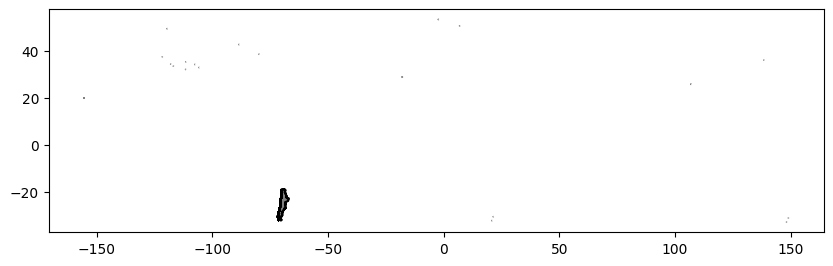

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black')
hexagonos.plot(ax=ax, edgecolor='gray', facecolor='none')
plt.show()

In [21]:
# a cada observatorio le asignamos el hexagono al que pertenece
obs['hex_id'] = obs.geometry.apply(lambda x: hexagonos[hexagonos.contains(x)].id.values[0] if not hexagonos[hexagonos.contains(x)].empty else None)
obs.head(1)

,Nombre,Altitud (m,Ubicación,Tipo,Estado,Año de In,Área Lent,geometry,hex_id
0,Very Large Array (VLA),2124,Nuevo México-USA,Radio,Operativo,1980,1256.6370614359173,POINT (-107.6184 34.0788),4690


### Subimos el archivo como asset a Google Earth Engine (manualmente), y lo leemos

In [33]:
asset_path = "projects/ee-tomasromero/assets/hexagonos"
hex_fc = ee.FeatureCollection(asset_path)

# Obtenemos la informacion de los Satelites

In [34]:
tasks = []

In [35]:
def export_satellite_band_to_hexagons(asset_path, image, band_name, output, scale=500, collection=True):
    if collection:
        image = image.select(band_name).mean()
    
    hex_fc = ee.FeatureCollection(asset_path)

    reduced = image.reduceRegions(
        collection=hex_fc,
        reducer=ee.Reducer.mean(),
        scale=scale
    )

    task = ee.batch.Export.table.toDrive(
        collection=reduced,
        description=f'{output}',
        fileNamePrefix=f'{output}',
        fileFormat='CSV'
    )
    return task


### Contaminacion Luminica
[VIIRS Stray Light Corrected Nighttime](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG?hl=es-419)

In [36]:
image = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, "avg_rad", "contaminacion_luminica"))

## Nubosidad
[Terra Atmosphere Monthly Global Product](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3?hl=es-419)

In [37]:
image = ee.ImageCollection("MODIS/061/MOD08_M3") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FMean', "nubosidad1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Log_Mean_Mean', "nubosidad2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Mean_Uncertainty', "nubosidad3"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FStd', "nubosidad4"))


### Elevacion
[NASA SRTM Digital Elevation 30m](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003?hl=es-419)

In [38]:
image = ee.Image('USGS/SRTMGL1_003')

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'elevation', "elevacion", collection=False))

### Precipitacion
[TCHIRPS Daily: Climate Hazards Center InfraRed Precipitation](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=es-419)

In [39]:
image = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
                  .filter(ee.Filter.date(startDate, endDate))

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'precipitation', "precipitacion"))

### Calidad del aire
[Terra & Aqua MAIAC Land Aerosol Profundidad óptica Diario 1 km](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES?hl=es-419)

In [40]:
image = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
          .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_047', "calidad_aire1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_055', "calidad_aire2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Column_WV', "calidad_aire3"))

### Gases Atmosfericos
[Sentinel-5P OFFL AER AI: Índice de Aerosol UV fuera de línea ](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI?hl=es-419)

In [41]:
image = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI') \
          .filterDate(startDate, endDate)
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'absorbing_aerosol_index', "gases_atmosfericos"))

## Uso del Suelo
[ESA WorldCover 10m v100](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100?hl=es-419)


In [42]:
image = ee.Image('ESA/WorldCover/v100/2020')
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Map', "uso_suelo", collection=False))

### Urbanizacion Historica
[Landsat 8-9](https://developers.google.com/earth-engine/datasets/catalog/LANDSAT_LC08_C02_T1_L2?hl=es-419)

<div style="text-align:center">
    <iframe src="https://gifer.com/embed/PYh" width=480 height=480.000 frameBorder="0" allowFullScreen></iframe><p><a href="https://gifer.com">a través de GIFER</a></p>
</div>

### Pasamos toda la informacion de los satelites a csv, los cuales cargaran en drive

In [ ]:
# for t in tasks:
#     t.start()

### Cargamos cada csv y lo mergeamos con los hexagonos

In [46]:
matriz = pd.DataFrame()
matriz['id'] = hexagonos['id']
files = glob.glob("Datos/satelites/*.csv")
for file in files:
    columna = file.split("\\")[1].split(".")[0]
    matriz[columna] = pd.read_csv(file, index_col=0)['mean'].values

In [47]:
matriz

,id,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,1,0.297620,3290.080020,0.222616,9385.000000,2955.444444,291.222222,823.416667,0.061090,54.294491
1,2,0.314748,1413.343897,0.570114,9026.000000,2829.200000,216.100000,1124.083333,0.057439,60.000000
2,3,0.286782,1738.327591,0.089535,6981.333333,2620.500000,86.583333,2148.750000,0.141122,60.000000
3,4,0.334925,1153.981945,0.325510,5552.416667,2871.333333,21.750000,2559.750000,0.132876,60.000000
4,5,0.653313,1270.157879,0.503458,5552.416667,2871.333333,21.750000,2559.750000,0.212327,60.000000
...,...,...,...,...,...,...,...,...,...,...
4744,4745,0.279422,3735.427800,-1.832667,3239.916667,2948.333333,31.500000,2467.666667,2.737897,59.163237
4745,4746,0.279422,3735.427800,-1.832667,3239.916667,2948.333333,31.500000,2467.666667,2.737897,59.163237
4746,4747,0.298556,2279.066453,0.537688,7294.916667,3090.083333,78.500000,1854.583333,0.071919,57.169125
4747,4748,0.301977,923.629921,0.026068,6302.250000,3096.250000,36.416667,2488.250000,0.071618,59.858192


- Normalizar los valores y categorizar las columnas de los observatorios
- Anadir a obs, la info de matriz de cada observatorio
- Quitar de la matriz, los hexagonos que pertencen a los observatorios

# MODELO